In [2]:
import matplotlib.pyplot as plt
import cupy as np
import pickle
plt.style.use('seaborn-v0_8-dark-palette')
plt.rcParams.update({'font.size': 12})

In [1]:
color1 = '#005AB5'
color2 = '#DC3220'

0.06729858526586742
0.010645856990751419
0.07642197507911216


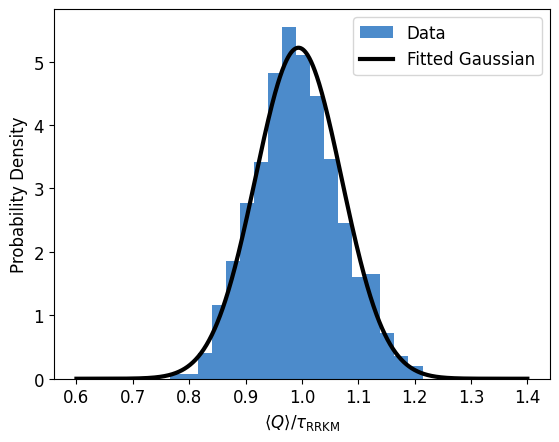

In [3]:
import pickle
import matplotlib.pyplot as plt
import cupy as np

name = 'dense_fixed'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)

import pandas as pd
for mean_spacing in mean_spacing_dict.keys():
    print(mean_spacing)
    rrkm = 2 * np.pi / mean_spacing
    rrkm_c6 = rrkm
    normalized = np.array(mean_spacing_dict[mean_spacing]).get() / rrkm_c6

    fig, ax = plt.subplots()
    df = pd.DataFrame({"Mean Spacing": normalized})
    plot1 = df.plot(kind="hist", density=True, bins=20,ax=ax, alpha=0.7, label="Data", color=color1)
    # plot2 = df.plot(kind="kde",ax=ax, color="black", label="Kernel Density Estimate")

    gaussian = lambda x, mu, sigma: np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))
    xrange = np.linspace(0.6, 1.4, 1000)
    plt.plot(xrange.get(), gaussian(xrange, np.mean(normalized), np.std(normalized)).get(), color="black", linewidth=3)

    print(np.mean(normalized) / rrkm_c6)
    # plt.xlim(-2, 2)
    plt.xlabel(r"$\langle Q \rangle / \tau_{\text{RRKM}}$")
    plt.ylabel("Probability Density")
    print(np.std(normalized))
    plt.legend(["Data", "Fitted Gaussian"])

    plt.savefig("dense_thermal.pdf", bbox_inches='tight')

    plt.show()

In [4]:
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

temp = 1

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]

abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2

Q = lambda E : abar / np.sqrt(E)

weights = relative_MB_weights(temp, energy_grid) * Q(energy_grid)
print(np.sum(relative_MB_weights(temp, energy_grid)) * dE)

new_thermal_delay = dE * weights

tauT = 2 * abar * np.sqrt(1/np.pi/temp)

print(np.sum(new_thermal_delay).item() / tauT)

energy_GOE_mat = np.array([200])
W_mat = np.array([200000])

weights = relative_MB_weights(temp, energy_grid) * wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
tauT = 2 * abar * np.sqrt(1 / np.pi / temp)
print(np.sum(weights) * dE / tauT)

ModuleNotFoundError: No module named 'collision_cp'

274.16760284403034
RRKM 0.04249041334566772
-0.0011940816902027117
0.9439008569839933


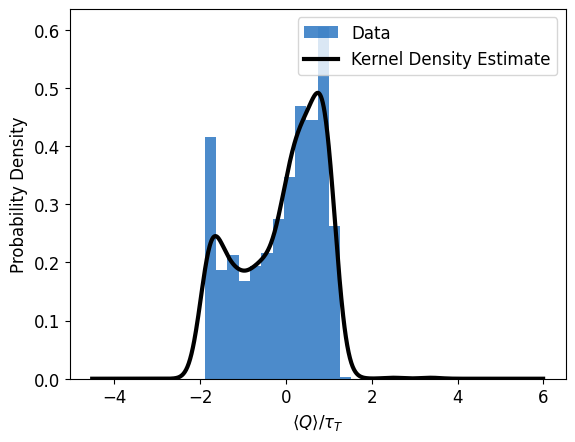

In [5]:
import pickle
import matplotlib.pyplot as plt
import cupy as np
import math

name = 'sparse_T=1'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)

import pandas as pd
for mean_spacing in mean_spacing_dict.keys():
    print(mean_spacing)
    abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
    tauT = 2 * abar * np.sqrt(1 / np.pi / 1)
    tauT = tauT.item()

    rrkm = 2 * np.pi / mean_spacing / tauT
    print("RRKM", rrkm)
    normalized = np.array(mean_spacing_dict[mean_spacing]).get() / tauT

    fig, ax = plt.subplots()
    df = pd.DataFrame({"Mean Spacing": normalized})
    plot1 = df.plot(kind="hist", density=True, bins=20,ax=ax, alpha=0.7, label="Data", color=color1)
    plot2 = df.plot(kind="kde",ax=ax, color="black", label="Kernel Density Estimate", linewidth=3)
    # vline = plt.axvline(rrkm, color="#49B3B1", label=r"$\tau_{\text{RRKM}}$", linestyle='--')
    print(np.mean(normalized) / rrkm_c6)
    # plt.xlim(-2, 2)
    plt.xlabel(r"$\langle Q \rangle / \tau_{T}$")
    plt.ylabel("Probability Density")
    print(np.std(normalized))
    # plt.legend(["Data", "Kernel Density Estimate", r"$\tau_{\text{RRKM}}$"])
    plt.legend(["Data", "Kernel Density Estimate"])

    plt.savefig("sparse_T=1_thermal.pdf")

    plt.show()

274.16760284403034
zeta -0.3294275401504679
RRKM 0.004249041334566771
Percent 565
-0.00032732848777700845
3.6648039222567217


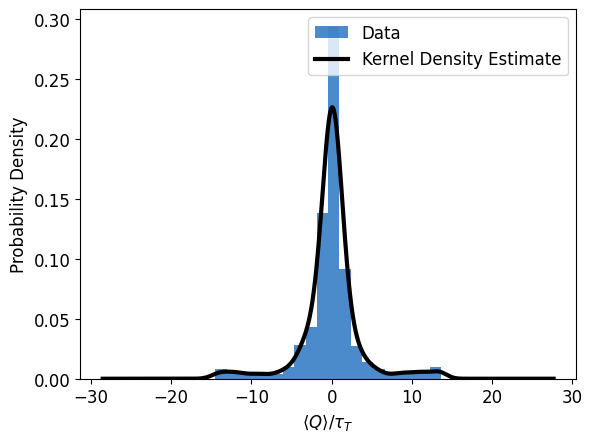

In [6]:
import pickle
import matplotlib.pyplot as plt
import cupy as np

name = 'sparse_T=0.01'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)

import pandas as pd
for mean_spacing in mean_spacing_dict.keys():
    print(mean_spacing)
    tauT = 1 / 0.01
    abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
    print("zeta", np.pi * (abar ** 2 - 1/3))
    tauT = 2*abar * np.sqrt(1/np.pi/0.01)
    tauT = tauT.item()

    rrkm = 2 * np.pi / mean_spacing / tauT
    print("RRKM", rrkm)
    normalized = np.array(mean_spacing_dict[mean_spacing]).get() / tauT

    print("Percent", np.sum(np.abs(np.array(mean_spacing_dict[mean_spacing]) / tauT) > 0.78).item())

    fig, ax = plt.subplots()
    df = pd.DataFrame({"Mean Spacing": normalized})
    plot1 = df.plot(kind="hist", density=True, bins=20,ax=ax, alpha=0.7, label="Data", color=color1)
    plot2 = df.plot(kind="kde",ax=ax, color="black", label="Kernel Density Estimate", linewidth=3)
    # vline = plt.axvline(rrkm, color="#49B3B1", label=r"$\tau_{\text{RRKM}}$", linestyle='--')
    print(np.mean(normalized) / rrkm_c6)
    # plt.xlim(-2, 2)
    plt.xlabel(r"$\langle Q \rangle / \tau_{T}$")
    plt.ylabel("Probability Density")
    print(np.std(normalized))
    # plt.legend(["Data", "Kernel Density Estimate", r"$\tau_{\text{RRKM}}$"])
    plt.legend(["Data", "Kernel Density Estimate"])

    plt.savefig("sparse_T=0.01_thermal.pdf")

    plt.show()

20
dict_keys([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9])
dict_keys([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4000000000000001, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0])
[array(0.99606451), array(0.99176096), array(0.99912208), array(0.98429479), array(0.98415533), array(0.99192885), array(0.9768029), array(0.97924785), array(0.95981606), array(0.97328333), array(0.97113523), array(0.98518064), array(0.98254696), array(0.97394249), array(0.98179297), array(0.96875039), array(0.96904542), array(0.9855412), array(0.97617629), array(0.97102383)]


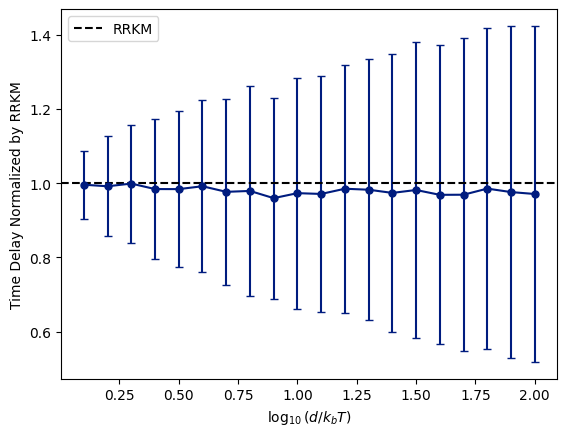

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]
[0.92075052 0.3406382 ] [[ 1.29614611e+27 -4.79309721e+26]
 [-4.79309721e+26  1.77246844e+26]]
Std
[3.60020293e+13 1.33134084e+13]


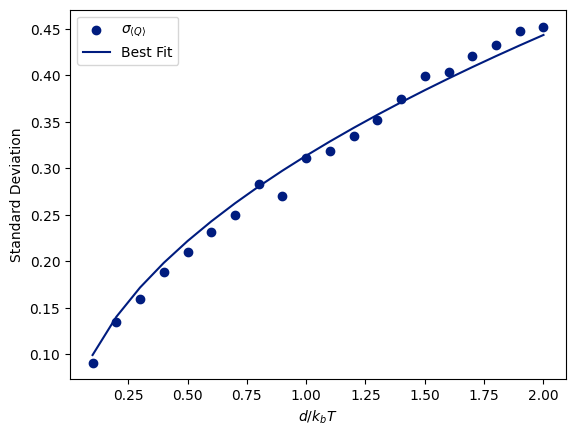

In [45]:
import pickle
name = 'sqrt'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)
print(len(mean_spacing_dict.keys()))

with open(f'mean_spacing_cluster.pkl', 'rb') as f:
    mean_spacing_cluster = pickle.load(f)
print(mean_spacing_cluster.keys())

plt.style.use('seaborn-v0_8-dark-palette')
means = []
stds = []
mean_spacings = []
keys = list(mean_spacing_dict.keys())
for mean_spacing in keys:
    data = np.array(mean_spacing_dict[mean_spacing])[:900]
    rrkm = 2 * np.pi / mean_spacing 

    # plt.hist(data.get() / rrkm, bins=50)
    # # plt.xlim(0, 2)
    # plt.xlabel(r"Time Delay ($\tau_{RRKM}$)")
    # plt.ylabel("Counts")
    # plt.show()

    means.append(np.mean(data / rrkm).get())
    stds.append(np.std(data / rrkm).get())
    mean_spacings.append(mean_spacing)
print(mean_spacing_dict.keys())
plt.errorbar(np.array(mean_spacings).get(), means, yerr=stds, fmt='o-', markersize=5, capsize=3)
plt.axhline(1, color="black", label=r"RRKM", linestyle='--')
print(means)
# plt.ylim(-2, 2)
# plt.xlim(-3, 3)
plt.xlabel(r"$\log_{10}(d / k_bT)$")
plt.ylabel(r"$\langle Q \rangle / \tau_{\text{RRKM}}$")
plt.ylabel(r"Time Delay Normalized by RRKM")
plt.legend()
# plt.savefig("delay_distribution.pdf")
# plt.savefig("delay_distribution.png", bbox_inches='tight')
plt.show()

plt.scatter(np.array(mean_spacings).get(), np.array(stds).get(), label=r"$\sigma_{\langle Q \rangle}$")
print(np.array(mean_spacings).get())

import scipy as sc
import numpy as np_actual
x = np.array(mean_spacings).get()
y = np.array(stds).get()

def func(x, c, a):
    return (c * a) * np_actual.pow(x, 1/2) 

popt, pcov = sc.optimize.curve_fit(func, x, y)
print(popt, pcov)
perr = np.sqrt(np.diag(pcov))
print("Std")
print(perr)

points = np.arange(0.1, 2.1, 0.1)
num_res = 1 / np.array(points)

plt.plot(np.array(points).get(), func(x, popt[0], popt[1]), label=r"Best Fit")
# plt.plot(np.array(points).get(), res.slope * np.array(points).get() + res.intercept)
# plt.xlim(0, 2)
# plt.ylim(0, 1)
plt.xlabel(r"$d / k_bT$")
plt.ylabel(r"Standard Deviation")
plt.legend()
plt.savefig("delay_distribution_std.pdf", bbox_inches='tight')

20
dict_keys([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4000000000000001, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0])
dict_keys(['delay', 'temp', 'spacing'])
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]
[0.31145246 0.56515397] [[ 2.56023618e-06 -7.37264025e-06]
 [-7.37264025e-06  9.50206189e-05]]
Std
[0.00160007 0.00974785]


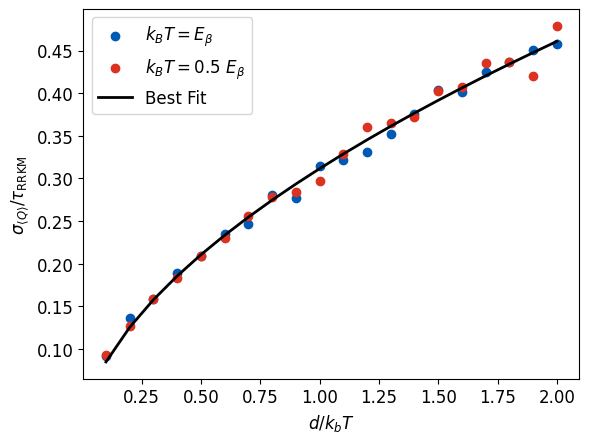

In [7]:
import pickle
name = 'sqrt'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)
print(len(mean_spacing_dict.keys()))

with open(f'mean_spacing_cluster.pkl', 'rb') as f:
    mean_spacing_cluster = pickle.load(f)
print(mean_spacing_cluster.keys())
print(mean_spacing_cluster[0.1].keys())

plt.style.use('seaborn-v0_8-dark-palette')
means = []
stds = []
mean_spacings = []
keys = list(mean_spacing_dict.keys())
for mean_spacing in keys:
    data = np.array(mean_spacing_dict[mean_spacing])
    rrkm = 2 * np.pi / mean_spacing 

    means.append(np.mean(data / rrkm).get())
    stds.append(np.std(data / rrkm).get())
    mean_spacings.append(mean_spacing)

means_cluster = []
stds_cluster = []
for ratio in mean_spacing_cluster:
    data = np.array(mean_spacing_cluster[ratio]['delay'])
    rrkm = 2 * np.pi / mean_spacing_cluster[ratio]['spacing']
    # print(mean_spacing_cluster[ratio]['temp'])

    means_cluster.append(np.mean(data / rrkm).get())
    stds_cluster.append(np.std(data / rrkm).get())

plt.scatter(np.array(mean_spacings).get(), np.array(stds).get(), label=r"$k_BT=E_\beta$", color=color1)
print(np.array(mean_spacings).get())

plt.scatter(np.array(mean_spacings).get(), np.array(stds_cluster).get(), label=r"$k_BT=0.5\ E_\beta$", color=color2)

import scipy as sc
import numpy as np_actual
x = np.append(np.array(mean_spacings), np.array(mean_spacings)).get()
y = np.append(np.array(stds), np.array(stds_cluster)).get()

def func(x, c, a):
    return (c) * np_actual.pow(x, a) 

popt, pcov = sc.optimize.curve_fit(func, x, y)
print(popt, pcov)
perr = np.sqrt(np.diag(pcov))
print("Std")
print(perr)

points = np.arange(0.1, 2.1, 0.1)
num_res = 1 / np.array(points)

plt.plot(np.array(points).get(), func(np.array(points).get(), popt[0], popt[1]), label=r"Best Fit", color="black", linewidth=2)
# plt.plot(np.array(points).get(), res.slope * np.array(points).get() + res.intercept)
# plt.xlim(0, 2)
# plt.ylim(0, 1)
plt.xlabel(r"$d / k_bT$")
plt.ylabel(r"$\sigma_{\langle Q \rangle} / \tau_{\rm RRKM}$")
plt.legend()
plt.savefig("delay_distribution_std.pdf", bbox_inches='tight')

[array(0.99660641), array(0.99370619), array(0.99924096), array(0.98328251), array(0.98259861), array(0.99348732), array(0.97674121), array(0.97669705), array(0.96416156), array(0.98102542), array(0.97133636), array(0.98160295), array(0.97833643), array(0.97651996), array(0.97941113), array(0.96865965), array(0.96789676), array(0.98205162), array(0.97291095), array(0.96316147)]


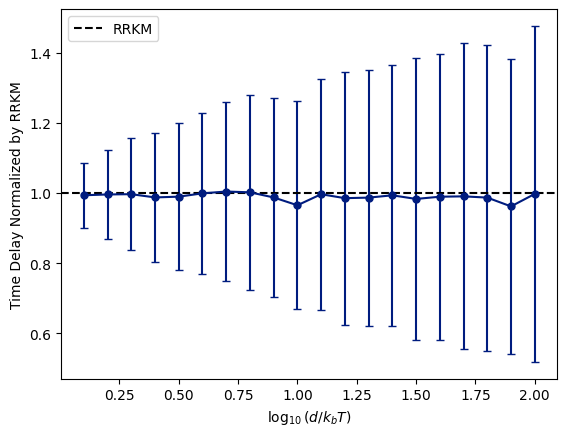

In [131]:
plt.errorbar(np.array(mean_spacings).get(), means_cluster, yerr=stds_cluster, fmt='o-', markersize=5, capsize=3)
plt.axhline(1, color="black", label=r"RRKM", linestyle='--')
print(means)
# plt.ylim(-2, 2)
# plt.xlim(-3, 3)
plt.xlabel(r"$\log_{10}(d / k_bT)$")
plt.ylabel(r"$\langle Q \rangle / \tau_{\text{RRKM}}$")
plt.ylabel(r"Time Delay Normalized by RRKM")
plt.legend()
# plt.savefig("delay_distribution.pdf")
# plt.savefig("delay_distribution.png", bbox_inches='tight')
plt.show()

8
dict_keys([0.08855077008666766, 0.1, 0.316, 1, 3.16, 10, 31.6, 100])
[array(0.99169827), array(0.99579429), array(0.96821125), array(0.93752946), array(0.81784844), array(0.35049329), array(-0.44364759)]


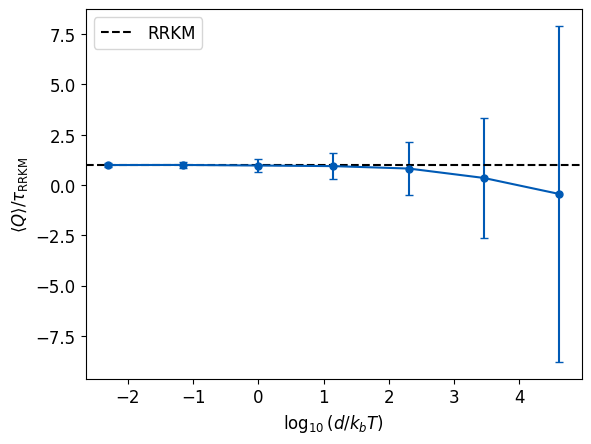

In [8]:
import pickle
with open(f'mean_spacing.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)
print(len(mean_spacing_dict.keys()))

plt.style.use('seaborn-v0_8-dark-palette')
means = []
stds = []
mean_spacings = []
keys = list(mean_spacing_dict.keys())
for mean_spacing in keys:
    if mean_spacing == keys[0]:
        continue
    data = np.array(mean_spacing_dict[mean_spacing])
    rrkm = 2 * np.pi / mean_spacing 

    # plt.hist(data.get() / rrkm, bins=50)
    # # plt.xlim(0, 2)
    # plt.xlabel(r"Time Delay ($\tau_{RRKM}$)")
    # plt.ylabel("Counts")
    # plt.show()

    means.append(np.mean(data / rrkm).get())
    stds.append(np.std(data / rrkm).get())
    mean_spacings.append(mean_spacing)
print(mean_spacing_dict.keys())
plt.errorbar(np.log(np.array(mean_spacings)).get(), means, yerr=stds, fmt='o-', markersize=5, capsize=3, color=color1)
plt.axhline(1, color="black", label=r"RRKM", linestyle='--')
print(means)
# plt.ylim(-2, 2)
# plt.xlim(-3, 3)
plt.xlabel(r"$\log_{10}(d / k_bT)$")
plt.ylabel(r"$\langle Q \rangle / \tau_{\text{RRKM}}$")
plt.legend()
plt.savefig("delay_distribution.pdf", bbox_inches='tight')
# plt.savefig("delay_distribution.png", bbox_inches='tight')
plt.show()

93.36281412688626
0.008745329660345347
0.08771817285097527


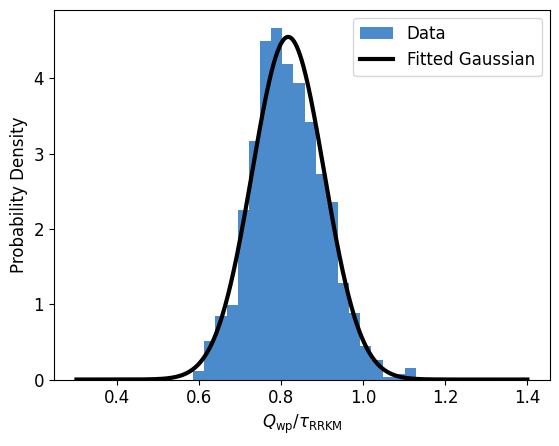

In [9]:
import cupy as np
import pickle

x0 = 200
k0 = 1
mean_spacing = 0.06729858526586742

with open("dense_wavepacket.pkl", "rb") as f:
    distances = pickle.load(f)

diff_dist = -x0 - np.array(distances) 
rrkm_c6 = 2 * np.pi / mean_spacing 
print(rrkm_c6)

normalized = diff_dist.get() / 2 / k0 / rrkm_c6

fig, ax = plt.subplots()
df = pd.DataFrame({"Mean Spacing": normalized})
plot1 = df.plot(kind="hist", density=True, bins=20,ax=ax, alpha=0.7, label="Data", color=color1)
# plot2 = df.plot(kind="kde",ax=ax, color="black", label="Kernel Density Estimate")

gaussian = lambda x, mu, sigma: np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))
xrange = np.linspace(0.3, 1.4, 1000)
plt.plot(xrange.get(), gaussian(xrange, np.mean(normalized), np.std(normalized)).get(), color="black", linewidth=3)

print(np.mean(normalized) / rrkm_c6)
# plt.xlim(-2, 2)
plt.xlabel(r"$Q_{\rm wp} / \tau_{\text{RRKM}}$")
plt.ylabel("Probability Density")
print(np.std(normalized))
plt.legend(["Data", "Fitted Gaussian"])

plt.savefig("dense_wavepacket.pdf", bbox_inches='tight')
plt.show()

In [10]:
import sys
sys.path.append('..')
from scipy.signal import find_peaks
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix
import pickle

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 1 / E_beta    # time

num_samples = 5000
scale = 1

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd

rrkm_c6 = 2 * np.pi / mean_spacing 

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

with open("gif.pkl", "rb") as f:
     energy_GOE_mat, W_mat, x_actual = pickle.load(f)
print(np.mean(energy_GOE_mat[1:] - energy_GOE_mat[:-1]))

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=100)

new_energies = np.array([])
peak_vals = energy_grid[peaks]

insert = np.array([i * dE / 500 for i in range(500)])

for energy in energy_grid:
    near_peak = False

    if len(peak_vals) > 0:
        diff = np.abs(energy - peak_vals)
        if np.min(diff) < 3 * dE:
            near_peak = True

    if near_peak:
        new_energies = np.append(new_energies, energy + insert)
    else:
        new_energies = np.append(new_energies, energy)

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))

0.06918338963913939
394309


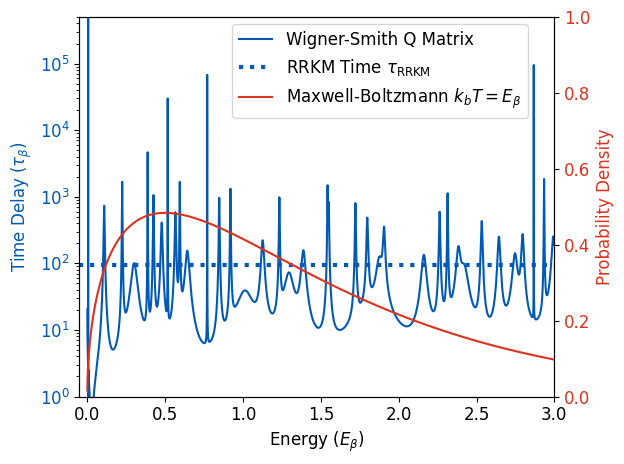

In [11]:
fig, ax1 = plt.subplots()
plt.style.use('seaborn-v0_8-dark-palette')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

color = color1
ax1.set_xlabel(r"Energy ($E_\beta$)")
ax1.set_ylabel(r'Time Delay ($\tau_\beta$)', color=color)
lns1 = ax1.semilogy(new_energies.get(), np.abs(new_time_delays).get(), label=r"Wigner-Smith Q Matrix", color=color)
lns3 = ax1.axhline(y=rrkm_c6, color=color, linestyle=':', linewidth=3, label=r"RRKM $\tau_{\rm RRKM}$")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(1, 5e5)
ax1.set_xlim(-0.05, 3)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = color2
ax2.set_ylabel('Probability Density', color=color)  # we already handled the x-label with ax1
lns2 = ax2.plot(new_energies.get(), relative_MB_weights(temp, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = E_\beta$", color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
# ax1.set_title(r"$d = $" + str(mean_spacing)[0:6] + r" $E_\beta$")
lns = lns1+lns2
labs = [l.get_label() for l in lns]
fig.legend(["Wigner-Smith Q Matrix", r"RRKM Time $\tau_{\rm RRKM}$", r"Maxwell-Boltzmann $k_bT = E_\beta$"], bbox_to_anchor=(0.85, 0.95))
# ax2.legend(r"Maxwell-Boltzmann $k_bT = E_\beta$")
# plt.savefig(f"x={str(mean_x)}.pdf")
plt.savefig(f"x=1.pdf", bbox_inches='tight')
plt.show()

In [12]:
import sys
sys.path.append('..')
from scipy.signal import find_peaks
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix
import pickle

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time

num_samples = 5000
scale = 1

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale

# thermal properties
temp = 0.01 / scale       # in terms of E6
num_resonances = 1000        # should be odd

rrkm_c6 = 2 * np.pi / mean_spacing 

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

with open("sparse_spectrum.pkl", "rb") as f:
     energy_GOE_mat, W_mat, x_actual = pickle.load(f)
print(np.mean(energy_GOE_mat[1:] - energy_GOE_mat[:-1]))

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=100)

new_energies = np.array([])
peak_vals = energy_grid[peaks]

insert = np.array([i * dE / 500 for i in range(500)])

for energy in energy_grid:
    near_peak = False

    if len(peak_vals) > 0:
        diff = np.abs(energy - peak_vals)
        if np.min(diff) < 3 * dE:
            near_peak = True

    if near_peak:
        new_energies = np.append(new_energies, energy + insert)
    else:
        new_energies = np.append(new_energies, energy)

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))

267.85830124255085
49999


49999
0.3161919792181338
61.505449780107085


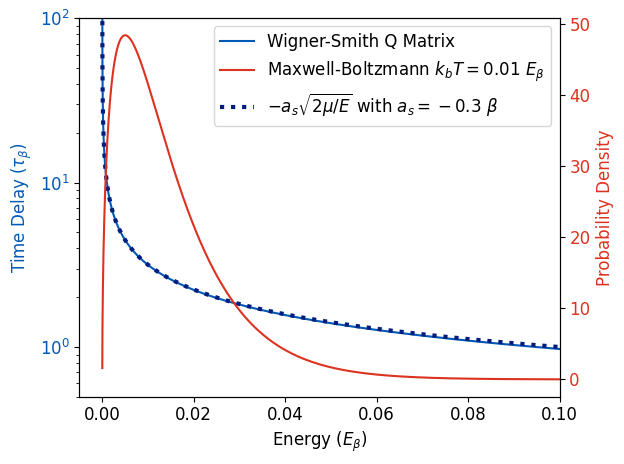

In [13]:
import numpy
from scipy.optimize import curve_fit

func = lambda E, a : a / numpy.sqrt(E)

print(len(new_energies))
popt, pcov = curve_fit(func, new_energies[:10000].get(), new_time_delays[:10000].get())
scat_length = popt[0]
print(scat_length)
print(scat_length * beta)

fig, ax1 = plt.subplots()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

color = color1
ax1.set_xlabel(r"Energy ($E_\beta$)")
ax1.set_ylabel(r'Time Delay ($\tau_\beta$)', color=color)
lns1 = ax1.semilogy(new_energies.get(), np.abs(new_time_delays).get(), label=r"Wigner-Smith Q Matrix", color=color)
lns3 = ax1.semilogy(new_energies.get(), func(new_energies.get(), popt[0]), label=r"$-a_s\sqrt{2\mu/E}$ with $a_s = -0.3\ \beta$", color=colors[0], linestyle='dotted', linewidth=3)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.5, 100)
ax1.set_xlim(-0.005, 0.1)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = color2
ax2.set_ylabel('Probability Density', color=color)  # we already handled the x-label with ax1
lns2 = ax2.plot(new_energies.get(), relative_MB_weights(temp, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = 0.01\ E_\beta$", color=color)
ax2.tick_params(axis='y', labelcolor=color)
# ax2.set_ylim(0, 1)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
# ax1.set_title(r"$d = $" + str(mean_spacing)[0:6] + r" $E_\beta$")
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs,loc="upper right")
plt.savefig(f"sparse_spectrum.pdf", bbox_inches='tight')
plt.show()

In [79]:
print(plt.rcParams['axes.prop_cycle'].by_key()['color'])


['#001C7F', '#017517', '#8C0900', '#7600A1', '#B8860B', '#006374']


In [14]:
import sys
sys.path.append('..')
from scipy.signal import find_peaks
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix
import pickle

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 1 / E_beta    # time

num_samples = 5000
scale = 1

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd

rrkm_c6 = 2 * np.pi / mean_spacing 

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

with open("dense_spectrum_x=0.1.pkl", "rb") as f:
     energy_GOE_mat, W_mat, x_actual = pickle.load(f)
print(np.mean(energy_GOE_mat[1:] - energy_GOE_mat[:-1]))

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=100)

new_energies = np.array([])
peak_vals = energy_grid[peaks]

insert = np.array([i * dE / 500 for i in range(500)])

for energy in energy_grid:
    near_peak = False

    if len(peak_vals) > 0:
        diff = np.abs(energy - peak_vals)
        if np.min(diff) < 3 * dE:
            near_peak = True

    if near_peak:
        new_energies = np.append(new_energies, energy + insert)
    else:
        new_energies = np.append(new_energies, energy)

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))

0.06695398457107987
496105


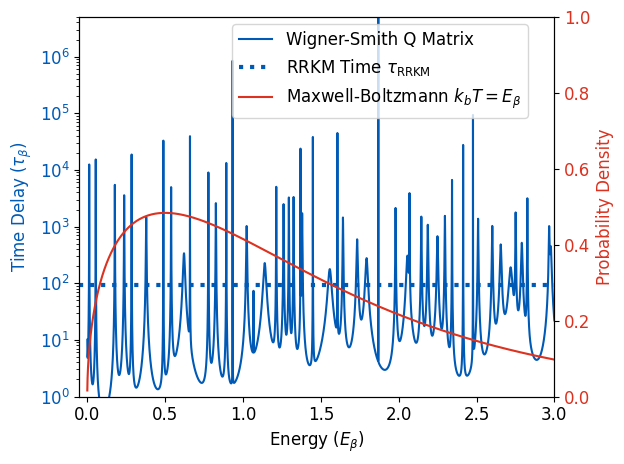

In [18]:
fig, ax1 = plt.subplots()
plt.style.use('seaborn-v0_8-dark-palette')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

color = color1
ax1.set_xlabel(r"Energy ($E_\beta$)")
ax1.set_ylabel(r'Time Delay ($\tau_\beta$)', color=color)
lns1 = ax1.semilogy(new_energies.get(), np.abs(new_time_delays).get(), label=r"Wigner-Smith Q Matrix", color=color)
lns3 = ax1.axhline(y=rrkm_c6, color=color, linestyle=':', linewidth=3, label=r"RRKM $\tau_{\rm RRKM}$")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(1, 5e6)
ax1.set_xlim(-0.05, 3)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = color2
ax2.set_ylabel('Probability Density', color=color)  # we already handled the x-label with ax1
lns2 = ax2.plot(new_energies.get(), relative_MB_weights(temp, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = E_\beta$", color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
# ax1.set_title(r"$d = $" + str(mean_spacing)[0:6] + r" $E_\beta$")
lns = lns1+lns2
labs = [l.get_label() for l in lns]
fig.legend(["Wigner-Smith Q Matrix", r"RRKM Time $\tau_{\rm RRKM}$", r"Maxwell-Boltzmann $k_bT = E_\beta$"], bbox_to_anchor=(0.85, 0.95))
# ax2.legend(r"Maxwell-Boltzmann $k_bT = E_\beta$")
# plt.savefig(f"x={str(mean_x)}.pdf")
plt.savefig(f"x=0.1.pdf", bbox_inches='tight')
plt.show()

In [19]:
import sys
sys.path.append('..')
from scipy.signal import find_peaks
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix
import pickle

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 1 / E_beta    # time

num_samples = 5000
scale = 1

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd

rrkm_c6 = 2 * np.pi / mean_spacing 

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

with open("dense_spectrum_x=10.pkl", "rb") as f:
     energy_GOE_mat, W_mat, x_actual = pickle.load(f)
print(np.mean(energy_GOE_mat[1:] - energy_GOE_mat[:-1]))

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=100)

new_energies = np.array([])
peak_vals = energy_grid[peaks]

insert = np.array([i * dE / 500 for i in range(500)])

for energy in energy_grid:
    near_peak = False

    if len(peak_vals) > 0:
        diff = np.abs(energy - peak_vals)
        if np.min(diff) < 3 * dE:
            near_peak = True

    if near_peak:
        new_energies = np.append(new_energies, energy + insert)
    else:
        new_energies = np.append(new_energies, energy)

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))

0.06765673599876856
459678


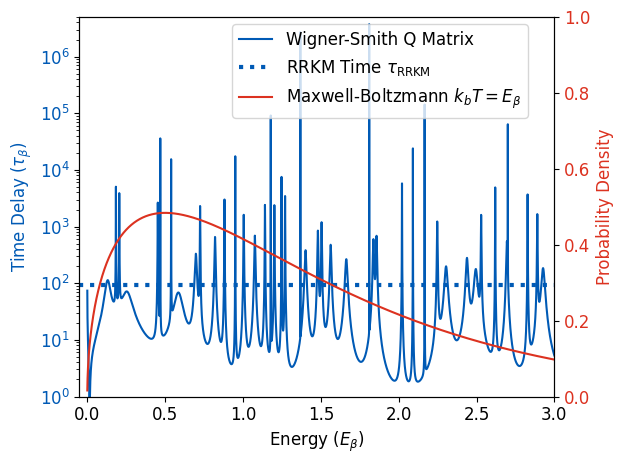

In [20]:
fig, ax1 = plt.subplots()
plt.style.use('seaborn-v0_8-dark-palette')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

color = color1
ax1.set_xlabel(r"Energy ($E_\beta$)")
ax1.set_ylabel(r'Time Delay ($\tau_\beta$)', color=color)
lns1 = ax1.semilogy(new_energies.get(), np.abs(new_time_delays).get(), label=r"Wigner-Smith Q Matrix", color=color)
lns3 = ax1.axhline(y=rrkm_c6, color=color, linestyle=':', linewidth=3, label=r"RRKM $\tau_{\rm RRKM}$")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(1, 5e6)
ax1.set_xlim(-0.05, 3)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = color2
ax2.set_ylabel('Probability Density', color=color)  # we already handled the x-label with ax1
lns2 = ax2.plot(new_energies.get(), relative_MB_weights(temp, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = E_\beta$", color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
# ax1.set_title(r"$d = $" + str(mean_spacing)[0:6] + r" $E_\beta$")
lns = lns1+lns2
labs = [l.get_label() for l in lns]
fig.legend(["Wigner-Smith Q Matrix", r"RRKM Time $\tau_{\rm RRKM}$", r"Maxwell-Boltzmann $k_bT = E_\beta$"], bbox_to_anchor=(0.85, 0.95))
# ax2.legend(r"Maxwell-Boltzmann $k_bT = E_\beta$")
# plt.savefig(f"x={str(mean_x)}.pdf")
plt.savefig(f"x=10.pdf", bbox_inches='tight')
plt.show()